In [8]:
import json
import pandas as pd
import re
import matplotlib.pyplot as plt

In [9]:
filename = 'sprakradet_clean.json'


def read_json(filename, sections=('question', 'answer')):
    if isinstance(sections, str):
        sections = [sections]

    with open(filename, 'r') as f:
        data = json.load(f)

    articles = pd.json_normalize(data)
    
    for section in sections:
        articles[section] = articles[section].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
    
    return(articles)

articles = read_json(filename=filename)

In [10]:
# I use the answers to check for language, because they are longer and probably includes the words I need.

# Regex from chatGPT UiO
NN_REGEX = re.compile(r'\b(eg|ikkje|vore|døme|ein|eit|korleis|kvar|kven|medan|dagar)\b', re.IGNORECASE)
BM_REGEX = re.compile(r'\b(jeg|ikke|være|eksempel|hvordan|hvem|hvor|mens|dager)\b', re.IGNORECASE)

def classify_nb_nn(text: str) -> str:
    if not isinstance(text, str):
        return "unknown"

    has_nn = bool(NN_REGEX.search(text))
    has_bm = bool(BM_REGEX.search(text))

    if has_nn and not has_bm:
        return "nynorsk"
    elif has_bm and not has_nn:
        return "bokmål"
    else:
        # both, or neither → ambiguous
        return "ukjent"


# Testing frequencies, but I am unsure if any of them really work.

NN_WORDS = {"eg", "ikkje", "me", "no", "vore", "seinare", "døme"}
BM_WORDS = {"jeg", "ikke", "vi", "nå", "vært", "senere", "eksempel"}

# pre-compile word regex to tokenize roughly
WORD_RE = re.compile(r"[A-Za-zÆØÅæøå]+", re.UNICODE)

def score_variant(text: str):
    text = text.lower()
    words = WORD_RE.findall(text)

    nn_hits = sum(w in NN_WORDS for w in words)
    bm_hits = sum(w in BM_WORDS for w in words)

    if nn_hits > bm_hits:
        return "nynorsk"
    elif bm_hits > nn_hits:
        return "bokmål"
    else:
        return "ukjent"

# Apply to your dataframe
# df is your DataFrame, 'answer' is the column with text / lists
articles["language"] = articles["answer"].apply(classify_nb_nn)
articles["language_2"] = articles["answer"].apply(score_variant)

Av de 1122 artiklene er 326 (29.06%) skrevet på nynorsk.
Av de 1122 artiklene er 201 (17.91%) skrevet på ukjent språk.
Av de 230 artiklene er 230 (20.50%) skrevet på nynorsk.
Av de 1122 artiklene er 145 (12.92%) skrevet på ukjent språk.


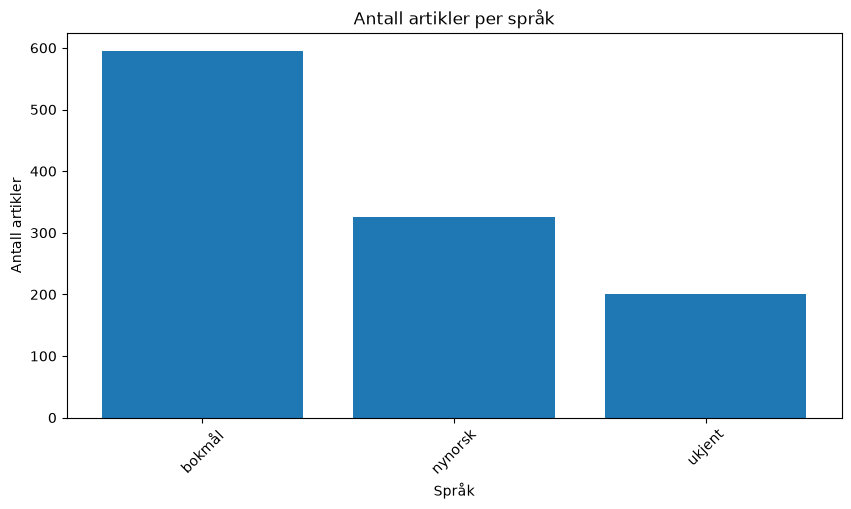

In [11]:
tot_articles = len(articles)
nn_articles = (articles['language'] == 'nynorsk').sum()
frac_nn = nn_articles / tot_articles * 100
unknown = (articles['language'] == 'ukjent').sum()
frac_unknown = unknown / tot_articles * 100
bm_articles = (articles['language'] == 'bokmål').sum()
frac_bm = bm_articles / tot_articles * 100


nn_articles_2 = (articles['language_2'] == 'nynorsk').sum()
frac_nn_2 = nn_articles_2 / tot_articles * 100
unknown_2 = (articles['language_2'] == 'ukjent').sum()
frac_unknown_2 = unknown_2 / tot_articles * 100



print(f'Av de {tot_articles} artiklene er {nn_articles} ({frac_nn:.2f}%) skrevet på nynorsk.')
print(f'Av de {tot_articles} artiklene er {unknown} ({frac_unknown:.2f}%) skrevet på ukjent språk.')
print(f'Av de {nn_articles_2} artiklene er {nn_articles_2} ({frac_nn_2:.2f}%) skrevet på nynorsk.')
print(f'Av de {tot_articles} artiklene er {unknown_2} ({frac_unknown_2:.2f}%) skrevet på ukjent språk.')


plt.figure(figsize=(10, 5))
plt.bar(['bokmål', 'nynorsk', 'ukjent'], [bm_articles, nn_articles, unknown])
plt.xticks(rotation=45)
plt.title('Antall artikler per språk')
plt.xlabel('Språk')
plt.ylabel('Antall artikler')
plt.show()